# 00: Setup and Data Overview

## Learning objectives
- Confirm your Python environment and basic plotting setup.
- Load synthetic GNSS site files used in this project.
- Review the language of forward and inverse models.

## Forward vs inverse model (plain language)
- **Forward model**: choose model parameters, predict data.
- **Inverse model**: start from data, estimate model parameters.

In compact form:

$$
\mathbf{d} = G\mathbf{m} + \mathbf{e}
$$

where $\mathbf{d}$ is data, $\mathbf{m}$ is model parameters, and $\mathbf{e}$ is error.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

Python version: 3.12.10
NumPy version: 2.2.5


## Load two GNSS site files
We use two synthetic station lists from `shakeout_data`:
- `SuGAr.sites`
- `SuMo.sites`

Each row includes site metadata and coordinates. We will load longitude/latitude.

In [2]:
data_dir = Path('../shakeout_data')

sugar_sites = np.loadtxt(data_dir / 'SuGAr.sites', usecols=(1, 2))
sumo_sites = np.loadtxt(data_dir / 'SuMo.sites', usecols=(1, 2))

sugar_lon, sugar_lat = sugar_sites[:, 0], sugar_sites[:, 1]
sumo_lon, sumo_lat = sumo_sites[:, 0], sumo_sites[:, 1]

print('SuGAr sites:', sugar_sites.shape[0])
print('SuMo sites :', sumo_sites.shape[0])

SuGAr sites: 60
SuMo sites : 61


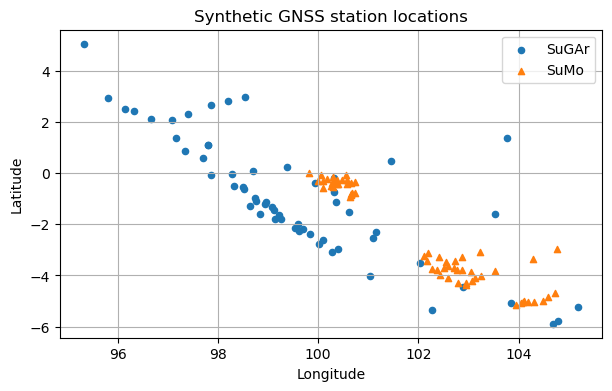

In [3]:
fig, ax = plt.subplots()
ax.scatter(sugar_lon, sugar_lat, label='SuGAr', marker='o', s=20)
ax.scatter(sumo_lon, sumo_lat, label='SuMo', marker='^', s=20)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Synthetic GNSS station locations')
ax.legend()
plt.show()

## Quick matrix example
Here is a tiny linear inverse setup with two model parameters.

$$
\mathbf{d} = G\mathbf{m}
$$

In [4]:
G = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
    [1.0, 2.0],
])
d = np.array([2.0, 2.5, 3.0])

m_est, _, _, _ = np.linalg.lstsq(G, d, rcond=None)

print('G shape:', G.shape)
print('d shape:', d.shape)
print('Estimated model m:', m_est)

G shape: (3, 2)
d shape: (3,)
Estimated model m: [2.  0.5]


## Exercise (TODO)
1. Print the first 5 rows of `SuGAr.sites` and `SuMo.sites`.
2. Compute the longitude and latitude range for each network.
3. Add labels or colors that improve readability of the station map.

## Checkpoint questions
1. What is the difference between a model parameter and an observation?
2. In $\mathbf{d}=G\mathbf{m}$, what does each column of $G$ represent physically?
3. Why is `np.linalg.lstsq` usually safer than directly using $(G^TG)^{-1}G^T$?

## Common mistakes
- Using the wrong relative path when running notebooks from different folders.
- Swapping longitude and latitude columns.
- Forgetting that matrix dimensions must match (`G @ m` needs compatible shapes).

## Summary
- You verified the environment and loaded project data.
- You reviewed core inverse-theory notation.
- You ran a minimal linear least-squares example.